# Практика 32. Приближённый поиск ближайших соседей: от точного KNN к LSH

## Бизнес-задача

Есть **архив текстовых сообщений**. Поисковый сервис должен по запросу возвращать **top-10 похожих документов** и выдерживать поток запросов в реальном времени.

Полный перебор даёт идеальное качество, но `O(N)` на запрос. Задача практики — **ускорить поиск, контролируя потерю качества**:

1. Построить **точный KNN** и зафиксировать его выдачу как эталон (ground truth).
2. Проверить на реальных данных, помогают ли **пространственные индексы** (KD-дерево, Ball Tree) — и с какой размерности они перестают работать.
3. Реализовать **LSH со случайными гиперплоскостями** с нуля.
4. Построить кривую **recall@10 против скорости** и выбрать рабочую точку.
5. Собрать **двухэтапный поиск**: LSH-отсечение → точное дораскачивание кандидатов.

## Датасет

[20 Newsgroups](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset) — ~18 800 сообщений из 20 тематических групп. Встроен в `scikit-learn`, скачивается одной строкой:

```python
from sklearn.datasets import fetch_20newsgroups
raw = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))
```

| Поле | Описание |
|------|----------|
| `data` | Текст сообщения |
| `target` | Индекс тематической группы (0–19) |
| `target_names` | Названия групп (`sci.space`, `rec.autos`, …) |

Язык — **английский**. Метки групп в поиске **не используются** — они нужны только для качественной проверки выдачи в блоке 9.

> **Если датасет не скачивается** (нет сети / прокси): замените корпус на любой другой набор из 5–20 тыс. текстов (`nltk.corpus.reuters`, выгрузка статей, датасет с HuggingFace). Вся остальная логика ноутбука не изменится — важно лишь, чтобы документов было ≥ 5 000.

## Методы

- **Векторизация:** TF-IDF → `TruncatedSVD` (LSA) → L2-нормализация.
- **Точный поиск:** `NearestNeighbors(algorithm="brute", metric="cosine")`.
- **Пространственные индексы:** `KDTree`, `BallTree` на срезах разной размерности.
- **Приближённый поиск:** LSH со случайными гиперплоскостями — **реализация с нуля**, без готовых библиотек.

## Метрики

| Метрика | Что показывает |
|---------|----------------|
| **Recall@10** | Доля эталонных соседей (из точного KNN), найденных приближённым методом |
| **QPS** | Запросов в секунду |
| **Доля просмотренных кандидатов** | Какая часть коллекции реально сравнивалась — честная цена скорости |

**Целевая точка:** recall@10 ≥ **0.80** при доле просмотренных кандидатов ≤ **25%**.


---

---
## Блок 0. Окружение

Зависимости: `numpy`, `scipy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`. Запустите ячейку ниже.

In [47]:
from __future__ import annotations

import json
import time
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from charset_normalizer.cli import query_yes_no
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import BallTree, KDTree, NearestNeighbors
from sklearn.preprocessing import normalize
from sympy import vectorize
from sympy.codegen import Print

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

RANDOM_STATE = 42
SAMPLE_SIZE = 8_000
TOP_K = 10
SVD_COMPONENTS = 256
N_QUERIES = 200
DIMS_TO_TEST = [2, 4, 8, 16, 32, 64, 128, 256]

rng = np.random.RandomState(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("Окружение готово")

Окружение готово


---
## Блок 1. Загрузка данных

**Цель:** получить рабочий датафрейм `df`.

**Сделайте:**
1. Загрузите корпус: `fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))`.
   Параметр `remove` обязателен — иначе документы одной группы «склеятся» по служебным заголовкам, и поиск будет находить не смысл, а шапку письма.
2. Соберите `df` с колонками `text`, `target`, `group` (название группы по `target_names`).
3. Добавьте `doc_id` — целочисленный индекс строки.
4. Отбросьте документы короче 30 слов: слишком короткие тексты дают вырожденные векторы.
5. Если задан `SAMPLE_SIZE` — случайная подвыборка с `random_state=RANDOM_STATE`, после чего **переиндексируйте** `doc_id` заново (он будет использоваться как позиция строки в матрице).
6. Выведите `shape`, число групп и `df.head(3)`.

**Вывод:** сколько документов осталось после фильтрации?

In [48]:
raw = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)

df = pd.DataFrame({
    "text": raw.data,
    "target": raw.target,
    "group": [raw.target_names[t] for t in raw.target],
})

df['num_words'] = df['text'].str.split().str.len().fillna(0).astype(int)

n_before = len(df)
df = df[df['num_words'] >= 30]
print(f' Original df length: {n_before}, new length: {len(df)}, {n_before - len(df)} rows deleted')

if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

print(f' Len df = {len(df)}')

df = df.reset_index(drop=True)
df['doc_id'] = np.arange(len(df))
print(f' {df.head()}')

assert (df["doc_id"].values == np.arange(len(df))).all()

print("shape:", df.shape)
print("groups:", df["group"].nunique())
display(df.head(3))

 Original df length: 18846, new length: 15521, 3325 rows deleted
 Len df = 8000
                                                 text  target  \
0  \n\n\nWhat makes you say that the guns were il...      19   
1  Yet another XView question: is there an (easy)...       5   
2  Actually, many of us have noted this. We have ...      11   
3  Hello Netters,\n\nI would like to find out inf...       7   
4  ... there was a post originating from Russia a...       6   

                group  num_words  doc_id  
0  talk.religion.misc         36       0  
1      comp.windows.x         45       1  
2           sci.crypt        108       2  
3           rec.autos         71       3  
4        misc.forsale         57       4  
shape: (8000, 5)
groups: 20


,text,target,group,num_words,doc_id
0,\n\n\nWhat makes you say that the guns were il...,19,talk.religion.misc,36,0
1,Yet another XView question: is there an (easy)...,5,comp.windows.x,45,1
2,"Actually, many of us have noted this. We have ...",11,sci.crypt,108,2


---
## Блок 2. EDA

**Цель:** понять, с каким корпусом предстоит работать.

**Сделайте (таблица + 2 графика):**
1. Таблица качества: число документов, пропуски, дубликаты по тексту, медианная и средняя длина в словах.
2. Гистограмма длины документа в словах (полезно обрезать хвост по 99-му перцентилю или взять `log`-шкалу).
3. Barplot: число документов по группам — насколько корпус сбалансирован.

**Вывод (2–3 предложения):** какие свойства корпуса повлияют на поиск — длина документов, дубликаты, дисбаланс групп?

In [51]:
# ВАШ КОД — блок 2
quality = pd.DataFrame({
    "indicator": [
        "documents",
        "missing values in text",
        "duplicate texts",
        "median length (words)",
        "mean length (words)",
        "minimum length (words)",
        "maximum length (words)",
    ],
    "meaning": [
        len(df),
        int(df['text'].isna().sum()),
        int(df['text'].duplicated().sum()),
        float(df['num_words'].median()),
        float(df['num_words'].mean()),
        int(df['num_words'].min()),
        int(df['num_words'].max()),
    ],
})
display(quality)

,indicator,meaning
0,documents,8000.000000
1,missing values in text,0.000000
2,duplicate texts,14.000000
3,median length (words),105.000000
4,mean length (words),219.512375
5,minimum length (words),30.000000
6,maximum length (words),11765.000000


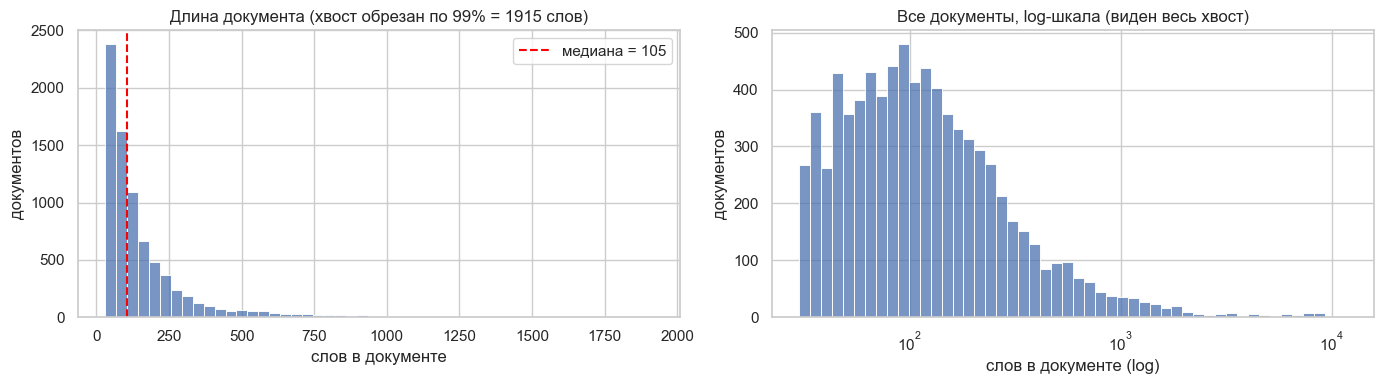

In [53]:
p99 = df['num_words'].quantile(0.99)
med = df['num_words'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df.loc[df["num_words"] <= p99, "num_words"], bins=50, ax=axes[0])
axes[0].axvline(med, color="red", linestyle="--", label=f"медиана = {med:.0f}")
axes[0].set_title(f"Длина документа (хвост обрезан по 99% = {p99:.0f} слов)")
axes[0].set_xlabel("слов в документе")
axes[0].set_ylabel("документов")
axes[0].legend()

sns.histplot(df["num_words"], bins=50, log_scale=True, ax=axes[1])
axes[1].set_title("Все документы, log-шкала (виден весь хвост)")
axes[1].set_xlabel("слов в документе (log)")
axes[1].set_ylabel("документов")

plt.tight_layout()
plt.show()

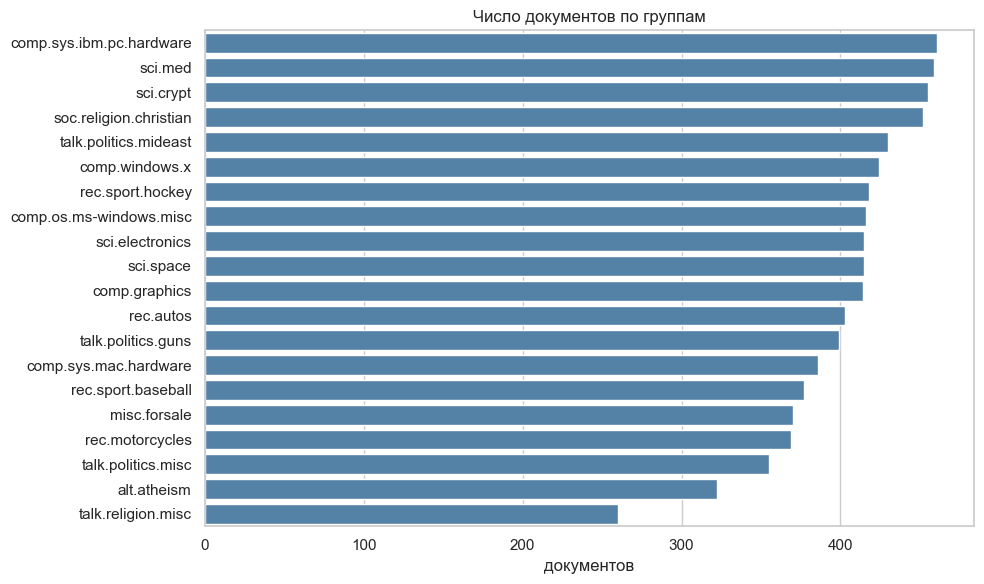

самая большая группа: comp.sys.ibm.pc.hardware — 461
самая маленькая:      talk.religion.misc — 260
перекос макс/мин:     1.77x


In [54]:
group_counts = df["group"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=group_counts.values, y=group_counts.index, color="steelblue")
plt.title("Число документов по группам")
plt.xlabel("документов")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(f"самая большая группа: {group_counts.idxmax()} — {group_counts.max()}")
print(f"самая маленькая:      {group_counts.idxmin()} — {group_counts.min()}")
print(f"перекос макс/мин:     {group_counts.max() / group_counts.min():.2f}x")

---
## Блок 3. Векторизация: TF-IDF

**Цель:** разреженная матрица признаков.

**Сделайте:**
1. `TfidfVectorizer` на `df["text"]`. В комментарии обоснуйте выбор `max_features`, `min_df`, `max_df`, `stop_words`.
   Ориентир: `min_df=3` убирает опечатки и уникальный мусор, `max_df=0.6` — слова, встречающиеся почти везде.
2. Постройте матрицу `X`.
3. Выведите размерность и **плотность** матрицы: `X.nnz / (X.shape[0] * X.shape[1])`.

**Вывод:** какая доля ячеек ненулевая? Почему такую матрицу нельзя просто перевести в плотный формат — прикиньте, сколько гигабайт занял бы `X.toarray()` во `float64`.

In [55]:
# ВАШ КОД — блок 3
# TfidfVectorizer, X, размерность, плотность, оценка памяти
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=3,
    max_df=0.6,
    max_features=50000,
    sublinear_tf=True,
)

In [58]:
X = vectorizer.fit_transform(df["text"])
print(X.shape)

(8000, 23315)


In [66]:
n_docs, n_terms = X.shape
total_cells = n_docs * n_terms
density = X.nnz / total_cells
print(f'non-zeros cells :{X.nnz:,} of {total_cells:,}')
print(f'density {density:.5f}, ({density * 100:.3f}%)')

non-zeros cells :549,979 of 186,520,000
density 0.00295, (0.295%)


In [67]:
sparse_mb = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1024**2
dense_gb = total_cells * 8 / 1024**3
print(f"разница: в {dense_gb * 1024 / sparse_mb:.0f} раз")

разница: в 225 раз


In [72]:
feature_names = vectorizer.get_feature_names_out()
row = X[5].toarray().ravel()
top = np.argsort(row)[::-1][:10]

for i in top:
    print(f"  {feature_names[i]:<20} {row[i]:.3f}")

  pick                 0.328
  crts                 0.316
  emissions            0.283
  tempest              0.280
  becuase              0.274
  refute               0.272
  verify               0.240
  picked               0.221
  controller           0.197
  necessarily          0.195


---
## Блок 4. Эмбеддинги: LSA + нормализация

**Цель:** плотные векторы фиксированной размерности.

**Сделайте:**
1. `TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)` → матрица `E`.
2. **L2-нормализуйте** строки `E` (`sklearn.preprocessing.normalize` или своя функция).
3. Выведите `E.shape`, суммарную объяснённую дисперсию и размер `E` в мегабайтах (`E.nbytes / 1024**2`).
4. Постройте график накопленной объяснённой дисперсии по числу компонент.

**Вопрос к выводу:** после L2-нормализации косинусное сходство превращается в обычное скалярное произведение `E @ q`. Почему это верно и что это даёт с точки зрения скорости?

In [79]:
# ВАШ КОД — блок 4
# TruncatedSVD, normalize, shape, explained_variance, график
svd = TruncatedSVD(
    n_components=SVD_COMPONENTS,
    random_state=RANDOM_STATE,
)

E_raw = svd.fit_transform(X)
E = normalize(E_raw)

In [80]:
explained = svd.explained_variance_ratio_
cum = np.cumsum(explained)

print(f"объяснённая дисперсия: {cum[-1]:.3f}  ({cum[-1] * 100:.1f}%)")
print(f"размер E в памяти: {E.nbytes / 1024**2:.1f} МБ")

norms = np.linalg.norm(E, axis=1)
print(f"длина строк после normalize: от {norms.min():.6f} до {norms.max():.6f}")

for k in (10, 50, 100, 256):
    if k <= len(cum):
        print(f"  первые {k:>3} компонент объясняют {cum[k - 1] * 100:5.1f}%")

объяснённая дисперсия: 0.194  (19.4%)
размер E в памяти: 15.6 МБ
длина строк после normalize: от 1.000000 до 1.000000
  первые  10 компонент объясняют   2.4%
  первые  50 компонент объясняют   6.6%
  первые 100 компонент объясняют  10.5%
  первые 256 компонент объясняют  19.4%


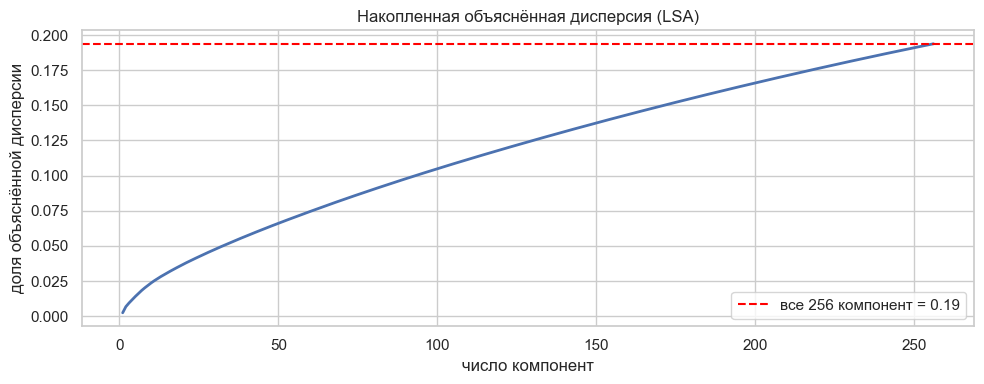

In [82]:
plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(cum) + 1), cum, linewidth=2)
plt.axhline(cum[-1], color="red", linestyle="--",
            label=f"все {len(cum)} компонент = {cum[-1]:.2f}")
plt.title("Накопленная объяснённая дисперсия (LSA)")
plt.xlabel("число компонент")
plt.ylabel("доля объяснённой дисперсии")
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
print(E.shape)

(8000, 256)


---
## Блок 5. Точный KNN — эталон и базовая скорость

**Цель:** зафиксировать ground truth и точку отсчёта по скорости.

**Сделайте:**
1. Выберите `N_QUERIES` случайных `doc_id` — это запросы. Матрица запросов `Q = E[query_ids]`.
2. Постройте `NearestNeighbors(n_neighbors=TOP_K + 1, metric="cosine", algorithm="brute")` и обучите на `E`.
3. Получите эталонных соседей. **Исключите сам документ** из его выдачи (первый сосед — он сам, потому и `TOP_K + 1`).
4. Сохраните `ground_truth` — список `set` из `TOP_K` индексов на каждый запрос.
5. Замерьте время и посчитайте **QPS** = число запросов / время.

**Важно про замеры:** первый вызов включает прогрев (BLAS, аллокации) и завышен в разы. Сделайте один «холостой» вызов до замера, а сам замер усредните по 3 повторам.

**Вывод:** сколько QPS даёт полный перебор на вашей машине? Экстраполируйте: сколько это будет при коллекции в 10 млн документов?

In [86]:
# ВАШ КОД — блок 5

def measure_qps(fn, n_queries: int, repeats: int = 3) -> float:
    fn()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return n_queries / float(np.median(times))


# query_ids, Q, nn_brute, ground_truth, QPS

query_rng = np.random.RandomState(RANDOM_STATE)
query_ids = query_rng.choice(len(E), size=N_QUERIES, replace=False)
Q = E[query_ids]

print(Q.shape)
print(f"запросов: {len(query_ids)}, матрица запросов Q: {Q.shape}")

(200, 256)
запросов: 200, матрица запросов Q: (200, 256)


In [93]:
nn_brute = NearestNeighbors(n_neighbors=TOP_K+1, metric='cosine', algorithm='brute')
nn_brute.fit(E)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [95]:
distances, indices = nn_brute.kneighbors(Q)
print(f"kneighbors вернул: distances {distances.shape}, indices {indices.shape}")

self_first = (indices[:, 0] == query_ids).mean()
print(f"первым соседом идёт сам документ: в {self_first:.1%} запросов")
print(f"расстояние до самого себя (ожидаем ~0): {distances[:, 0].max():.2e}")
print(f"среднее расстояние до ближайшего чужого: {distances[:, 1].mean():.3f}")

kneighbors вернул: distances (200, 11), indices (200, 11)
первым соседом идёт сам документ: в 99.5% запросов
расстояние до самого себя (ожидаем ~0): 8.88e-16
среднее расстояние до ближайшего чужого: 0.445


In [96]:
ground_truth = []
for qid, row in zip(query_ids, indices):
    neighbors = [int(i) for i in row if i != qid][:TOP_K]
    ground_truth.append(set(neighbors))

sizes = {len(s) for s in ground_truth}
print(f"размеры множеств ground_truth: {sizes}")
assert sizes == {TOP_K}, "в каком-то запросе не набралось TOP_K соседей"

размеры множеств ground_truth: {10}


In [97]:
brute_qps = measure_qps(lambda: nn_brute.kneighbors(Q), N_QUERIES)

print(f"\nQPS полного перебора: {brute_qps:,.0f}")
print(f"время на один запрос:  {1000 / brute_qps:.2f} мс")
print("\nэкстраполяция (время растёт линейно с числом документов):")
for n in (len(E), 100_000, 1_000_000, 10_000_000):
    print(f"  {n:>10,} документов → {brute_qps * len(E) / n:9.1f} QPS")


QPS полного перебора: 2,755
время на один запрос:  0.36 мс

экстраполяция (время растёт линейно с числом документов):
       8,000 документов →    2755.3 QPS
     100,000 документов →     220.4 QPS
   1,000,000 документов →      22.0 QPS
  10,000,000 документов →       2.2 QPS


---
## Блок 6. Пространственные индексы и проклятие размерности

**Цель:** проверить на данных, работают ли KD-дерево и Ball Tree на эмбеддингах.

**Сделайте:**
1. Для каждой размерности `d` из `DIMS_TO_TEST` возьмите срез `E[:, :d]` и **заново L2-нормализуйте** его.
2. Замерьте время поиска `TOP_K + 1` соседей для тех же `N_QUERIES` запросов тремя способами:
   - `NearestNeighbors(algorithm="brute")`,
   - `KDTree(...).query(...)`,
   - `BallTree(...).query(...)`.
   Время **построения** индекса замерьте отдельно от времени **поиска** — это разные вещи.
3. Соберите результаты в датафрейм и постройте график: ось X — размерность (log-шкала), ось Y — время поиска (log-шкала), три линии.

**Вывод (обязательно с числами):**
- На какой размерности деревья ещё выигрывают у полного перебора?
- Начиная с какой — проигрывают, и во сколько раз на `d = 256`?
- Объясните механизм: почему именно отсечение ветвей перестаёт срабатывать?

In [98]:
# цикл по DIMS_TO_TEST, замеры build/query для brute/KDTree/BallTree, датафрейм, график, вывод
records = []

for d in DIMS_TO_TEST:
    E_d = normalize(E[:, :d])
    Q_d = E_d[query_ids]

    t0 = time.perf_counter()
    nn_d = NearestNeighbors(n_neighbors=TOP_K + 1, metric="euclidean", algorithm="brute").fit(E_d)
    build_brute = time.perf_counter() - t0

    t0 = time.perf_counter()
    kdt = KDTree(E_d)
    build_kd = time.perf_counter() - t0

    t0 = time.perf_counter()
    bt = BallTree(E_d)
    build_ball = time.perf_counter() - t0

    qps = {
        "brute":    measure_qps(lambda: nn_d.kneighbors(Q_d), N_QUERIES),
        "kdtree":   measure_qps(lambda: kdt.query(Q_d, k=TOP_K + 1), N_QUERIES),
        "balltree": measure_qps(lambda: bt.query(Q_d, k=TOP_K + 1), N_QUERIES),
    }
    build = {"brute": build_brute, "kdtree": build_kd, "balltree": build_ball}

    _, idx_b = nn_d.kneighbors(Q_d)
    _, idx_k = kdt.query(Q_d, k=TOP_K + 1)
    overlap = np.mean([len(set(a) & set(b)) / (TOP_K + 1) for a, b in zip(idx_b, idx_k)])

    for method in ("brute", "kdtree", "balltree"):
        records.append({
            "dim": d,
            "method": method,
            "build_s": build[method],
            "query_ms": 1000 / qps[method],
            "qps": qps[method],
        })

    print(f"d={d:>3}: brute {qps['brute']:8.1f} | kdtree {qps['kdtree']:8.1f} | "
          f"balltree {qps['balltree']:8.1f} QPS   (совпадение kdtree с brute: {overlap:.3f})")

trees = pd.DataFrame(records)

d=  2: brute 106022.1 | kdtree 541272.0 | balltree 167350.0 QPS   (совпадение kdtree с brute: 1.000)
d=  4: brute 106661.0 | kdtree 239377.6 | balltree  54473.6 QPS   (совпадение kdtree с brute: 1.000)
d=  8: brute 100740.4 | kdtree  34277.1 | balltree  13806.7 QPS   (совпадение kdtree с brute: 1.000)
d= 16: brute  96362.3 | kdtree   6413.5 | balltree   7152.7 QPS   (совпадение kdtree с brute: 1.000)
d= 32: brute 123122.4 | kdtree   3314.9 | balltree   4376.8 QPS   (совпадение kdtree с brute: 1.000)
d= 64: brute  84238.9 | kdtree   1888.4 | balltree   2274.6 QPS   (совпадение kdtree с brute: 1.000)
d=128: brute  62774.6 | kdtree    830.5 | balltree    912.0 QPS   (совпадение kdtree с brute: 1.000)
d=256: brute  31984.1 | kdtree    394.1 | balltree    422.4 QPS   (совпадение kdtree с brute: 1.000)



время одного запроса, мс:


method,balltree,brute,kdtree
dim,,,
2,0.006,0.009,0.002
4,0.018,0.009,0.004
8,0.072,0.010,0.029
16,0.140,0.010,0.156
32,0.228,0.008,0.302
64,0.440,0.012,0.530
128,1.097,0.016,1.204
256,2.367,0.031,2.537


время построения индекса, с:


method,balltree,brute,kdtree
dim,,,
2,0.003,0.000,0.004
4,0.003,0.000,0.004
8,0.005,0.000,0.005
16,0.007,0.000,0.014
32,0.012,0.000,0.024
64,0.024,0.001,0.047
128,0.055,0.001,0.078
256,0.136,0.002,0.181


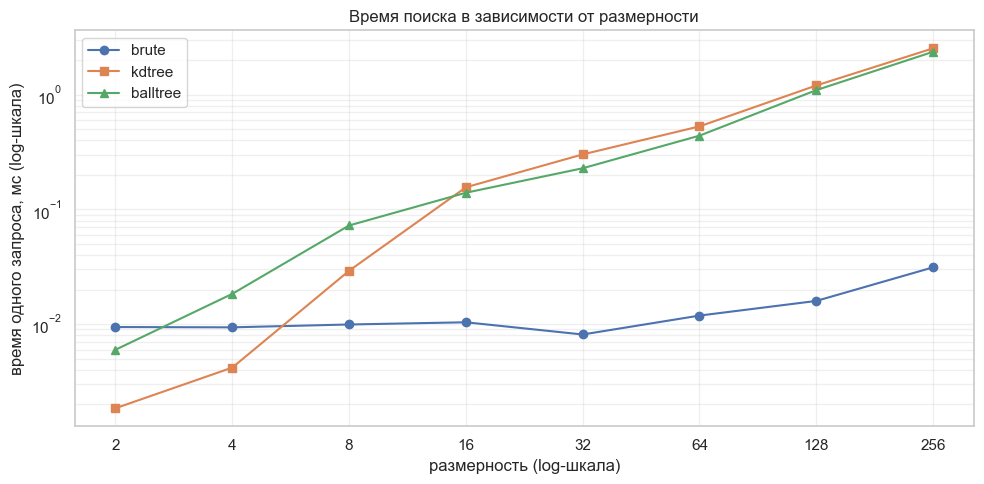

In [99]:
print("\nвремя одного запроса, мс:")
display(trees.pivot(index="dim", columns="method", values="query_ms").round(3))

print("время построения индекса, с:")
display(trees.pivot(index="dim", columns="method", values="build_s").round(3))

plt.figure(figsize=(10, 5))
for method, marker in [("brute", "o"), ("kdtree", "s"), ("balltree", "^")]:
    sub = trees[trees["method"] == method].sort_values("dim")
    plt.plot(sub["dim"], sub["query_ms"], marker=marker, label=method)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(DIMS_TO_TEST, [str(d) for d in DIMS_TO_TEST])
plt.title("Время поиска в зависимости от размерности")
plt.xlabel("размерность (log-шкала)")
plt.ylabel("время одного запроса, мс (log-шкала)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [100]:
# --- ключевые числа для вывода -------------------------------------------
pivot = trees.pivot(index="dim", columns="method", values="query_ms")
ratio = pd.DataFrame({
    "kdtree / brute": pivot["kdtree"] / pivot["brute"],
    "balltree / brute": pivot["balltree"] / pivot["brute"],
}).round(2)

print("во сколько раз дерево медленнее перебора:")
display(ratio)

kd_slowdown_256 = ratio.loc[256, "kdtree / brute"]
wins = ratio.index[ratio["kdtree / brute"] < 1].tolist()

print(f"\nKD-дерево выигрывает у перебора на размерностях: {wins}")
print(f"KD-дерево на d=256 медленнее перебора в {kd_slowdown_256:.1f} раз")

во сколько раз дерево медленнее перебора:


,kdtree / brute,balltree / brute
dim,,
2,0.20,0.63
4,0.45,1.96
8,2.94,7.30
16,15.02,13.47
32,37.14,28.13
64,44.61,37.03
128,75.59,68.83
256,81.15,75.72



KD-дерево выигрывает у перебора на размерностях: [2, 4]
KD-дерево на d=256 медленнее перебора в 81.2 раз


---
## Блок 7. LSH со случайными гиперплоскостями

**Цель:** реализовать LSH с нуля.

### Идея

Берём `n_bits` случайных гиперплоскостей, проходящих через начало координат (задаются нормалями — столбцами матрицы `P` формы `(dim, n_bits)`, заполненной из `randn`). Для вектора `v` знак `v @ P` даёт битовую подпись: бит равен 1, если `v @ pᵢ > 0`. Подпись упаковывается в целое число — это ключ бакета.

Одна таблица легко теряет настоящего соседа (он мог оказаться по другую сторону одной из плоскостей), поэтому строим `n_tables` независимых таблиц и объединяем кандидатов из всех.

**Сделайте:**

### `build_lsh(E, n_bits, n_tables, seed)`
Возвращает список таблиц. Каждая таблица — `(P, buckets)`, где `buckets: dict[int, list[int]]` отображает код подписи в список `doc_id`.
Подсказка по упаковке битов: `codes = (E @ P > 0) @ (1 << np.arange(n_bits))`.

### `lsh_candidates(tables, q)`
Возвращает `set` кандидатов: объединение бакетов, в которые попал запрос `q` во всех таблицах.

**Проверьте:**
1. Постройте LSH с `n_bits=8`, `n_tables=5`.
2. Выведите распределение размеров бакетов: сколько всего непустых, медиана и максимум. Насколько равномерно заполнены бакеты?
3. Возьмите один запрос, выведите число кандидатов и его долю от размера коллекции.

**Вывод:** равномерно ли распределились документы? Что означает очень большой бакет?

In [101]:
# ВАШ КОД — блок 7

def build_lsh(E: np.ndarray, n_bits: int, n_tables: int, seed: int = 0) -> list:
    rng_lsh = np.random.RandomState(seed)
    dim = E.shape[1]
    powers = 1 << np.arange(n_bits, dtype=np.int64)
    tables = []

    for _ in range(n_tables):
        P = rng_lsh.randn(dim, n_bits)
        codes = (E @ P > 0) @ powers

        buckets = defaultdict(list)
        for doc_id, code in enumerate(codes):
            buckets[int(code)].append(doc_id)

        tables.append((P, dict(buckets)))

    return tables

In [102]:
def lsh_candidates(tables: list, q: np.ndarray) -> set[int]:
    """Объединение бакетов запроса по всем таблицам."""
    cand = set()
    for P, buckets in tables:
        powers = 1 << np.arange(P.shape[1], dtype=np.int64)
        code = int((q @ P > 0) @ powers)
        cand.update(buckets.get(code, ()))
    return cand

In [103]:
N_BITS, N_TABLES = 8, 5
tables = build_lsh(E, n_bits=N_BITS, n_tables=N_TABLES, seed=RANDOM_STATE)
print(f"таблиц: {len(tables)}, бит в подписи: {N_BITS}, "
      f"возможных бакетов: 2^{N_BITS} = {2 ** N_BITS}")

таблиц: 5, бит в подписи: 8, возможных бакетов: 2^8 = 256



размеры бакетов по таблицам:
  таблица 0: непустых 256/256, медиана   26.0, мин   5, макс   125 (1.6% коллекции)
  таблица 1: непустых 256/256, медиана   28.5, мин   4, макс    87 (1.1% коллекции)
  таблица 2: непустых 256/256, медиана   28.0, мин   5, макс   112 (1.4% коллекции)
  таблица 3: непустых 256/256, медиана   25.0, мин   6, макс   123 (1.5% коллекции)
  таблица 4: непустых 256/256, медиана   25.0, мин   1, макс   122 (1.5% коллекции)


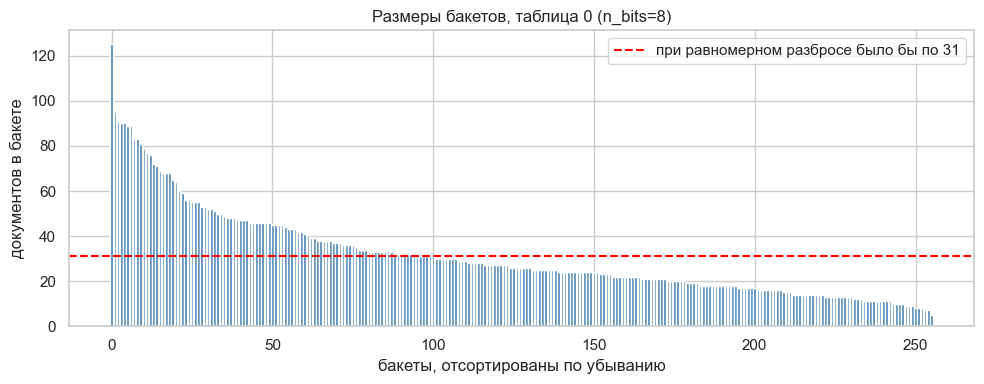

In [104]:
print("\nразмеры бакетов по таблицам:")
for t, (P, buckets) in enumerate(tables):
    sizes = np.array([len(v) for v in buckets.values()])
    print(f"  таблица {t}: непустых {len(buckets):>3}/{2 ** N_BITS}, "
          f"медиана {np.median(sizes):>6.1f}, мин {sizes.min():>3}, макс {sizes.max():>5} "
          f"({sizes.max() / len(E):.1%} коллекции)")

sizes0 = np.array(sorted((len(v) for v in tables[0][1].values()), reverse=True))
plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(sizes0)), sizes0, color="steelblue")
plt.axhline(len(E) / 2 ** N_BITS, color="red", linestyle="--",
            label=f"при равномерном разбросе было бы по {len(E) / 2 ** N_BITS:.0f}")
plt.title(f"Размеры бакетов, таблица 0 (n_bits={N_BITS})")
plt.xlabel("бакеты, отсортированы по убыванию")
plt.ylabel("документов в бакете")
plt.legend()
plt.tight_layout()
plt.show()

In [105]:
qid = int(query_ids[0])
cand = lsh_candidates(tables, E[qid])
print(f"запрос doc_id={qid} (группа {df.loc[qid, 'group']})")
print(f"  кандидатов: {len(cand)} = {len(cand) / len(E):.1%} коллекции")
print(f"  из {TOP_K} эталонных соседей попало в кандидаты: {len(ground_truth[0] & cand)}")

запрос doc_id=2215 (группа rec.autos)
  кандидатов: 159 = 2.0% коллекции
  из 10 эталонных соседей попало в кандидаты: 2


In [106]:
n_cand, hits = [], []
for i, qi in enumerate(query_ids):
    c = lsh_candidates(tables, E[qi])
    n_cand.append(len(c))
    hits.append(len(ground_truth[i] & c) / TOP_K)

print(f"\nв среднем по {N_QUERIES} запросам:")
print(f"  кандидатов: {np.mean(n_cand):.0f} ({np.mean(n_cand) / len(E):.1%} коллекции)")
print(f"  потолок recall@10 (доля эталона среди кандидатов): {np.mean(hits):.3f}")



в среднем по 200 запросам:
  кандидатов: 211 (2.6% коллекции)
  потолок recall@10 (доля эталона среди кандидатов): 0.162


In [107]:
print("\nвлияние числа таблиц (n_bits=8):")
for k in range(1, N_TABLES + 1):
    sub = tables[:k]
    cands = [lsh_candidates(sub, E[qi]) for qi in query_ids]
    ceil = np.mean([len(ground_truth[i] & c) / TOP_K for i, c in enumerate(cands)])
    share = np.mean([len(c) for c in cands]) / len(E)
    print(f"  {k} таблиц: кандидатов {share:>6.1%}, потолок recall {ceil:.3f}")


влияние числа таблиц (n_bits=8):
  1 таблиц: кандидатов   0.5%, потолок recall 0.030
  2 таблиц: кандидатов   1.0%, потолок recall 0.061
  3 таблиц: кандидатов   1.5%, потолок recall 0.095
  4 таблиц: кандидатов   2.1%, потолок recall 0.127
  5 таблиц: кандидатов   2.6%, потолок recall 0.162


---
## Блок 8. Двухэтапный поиск и метрики

**Цель:** превратить кандидатов в выдачу и честно измерить цену скорости.

**Сделайте:**

### `lsh_search(tables, q, top_k)`
1. Собрать кандидатов через `lsh_candidates`.
2. Посчитать **точное** сходство запроса только с кандидатами: для нормализованных векторов это `E[cand] @ q`.
3. Вернуть `top_k` лучших и число просмотренных кандидатов.

Это и есть двухэтапная схема: грубое отсечение — `O(1)`, точная оценка — `O(K)`.

### `evaluate(tables, ...)`
Возвращает `recall@10` (доля эталонных соседей из блока 5, попавших в выдачу LSH), среднее число кандидатов, долю просмотренной коллекции и QPS.

**Сетка экспериментов** — не менее 8 конфигураций, например `n_bits ∈ {6, 8, 10, 12, 16}` × `n_tables ∈ {1, 5, 10, 20, 40}`:

| n_bits | n_tables | recall@10 | ср. кандидатов | доля коллекции | QPS |
|--------|----------|-----------|----------------|----------------|-----|

**Постройте график** «recall@10 (X) против QPS (Y)» — каждая конфигурация точкой, подпишите точки. Это и есть кривая скорость/качество, по которой сравнивают ANN-методы.

**Вывод (3–5 предложений):**
- Как влияет **рост числа бит** при фиксированном числе таблиц? Почему?
- Как влияет **рост числа таблиц**? Чем за это платим?
- Какую конфигурацию вы выберете под требование recall@10 ≥ 0.80 при доле кандидатов ≤ 25% и почему?

In [108]:
# ВАШ КОД — блок 8

def lsh_search(tables: list, q: np.ndarray, top_k: int = TOP_K) -> tuple[list[int], int]:
    cand = lsh_candidates(tables, q)
    if not cand:
        return [], 0

    cand_arr = np.fromiter(cand, dtype=np.int64, count=len(cand))
    sims = E[cand_arr] @ q

    if len(cand_arr) > top_k:
        part = np.argpartition(-sims, top_k)[:top_k]
        order = part[np.argsort(-sims[part])]
    else:
        order = np.argsort(-sims)

    return cand_arr[order].tolist(), len(cand_arr)

In [109]:
def evaluate(tables: list, query_ids: np.ndarray, ground_truth: list[set],
             top_k: int = TOP_K) -> dict:
    recalls, n_cands = [], []

    for i, qid in enumerate(query_ids):
        found, n = lsh_search(tables, E[qid], top_k + 1)
        found = [d for d in found if d != qid][:top_k]
        recalls.append(len(set(found) & ground_truth[i]) / top_k)
        n_cands.append(n)

    qps = measure_qps(
        lambda: [lsh_search(tables, E[qid], top_k + 1) for qid in query_ids],
        len(query_ids),
    )

    mean_cand = float(np.mean(n_cands))
    return {
        "recall@10": float(np.mean(recalls)),
        "mean_candidates": mean_cand,
        "candidate_share": mean_cand / len(E),
        "qps": qps,
    }


In [110]:
BITS_GRID = [6, 8, 10, 12, 16]
TABLES_GRID = [1, 5, 10, 20, 40]

rows = []
for n_bits in BITS_GRID:
    for n_tables in TABLES_GRID:
        t0 = time.perf_counter()
        tbl = build_lsh(E, n_bits=n_bits, n_tables=n_tables, seed=RANDOM_STATE)
        build_s = time.perf_counter() - t0

        m = evaluate(tbl, query_ids, ground_truth)
        m.update({"n_bits": n_bits, "n_tables": n_tables, "build_s": build_s})
        rows.append(m)

        print(f"bits={n_bits:>2} tables={n_tables:>2}: recall={m['recall@10']:.3f}  "
              f"кандидатов={m['mean_candidates']:>6.0f} ({m['candidate_share']:>5.1%})  "
              f"QPS={m['qps']:>8.1f}")

grid = pd.DataFrame(rows)[["n_bits", "n_tables", "recall@10", "mean_candidates",
                           "candidate_share", "qps", "build_s"]]

print("\nполная таблица:")
display(grid.round({"recall@10": 3, "mean_candidates": 0,
                    "candidate_share": 3, "qps": 1, "build_s": 2}))

bits= 6 tables= 1: recall=0.076  кандидатов=   152 ( 1.9%)  QPS= 12849.9
bits= 6 tables= 5: recall=0.319  кандидатов=   778 ( 9.7%)  QPS=  1812.1
bits= 6 tables=10: recall=0.537  кандидатов=  1464 (18.3%)  QPS=   826.7
bits= 6 tables=20: recall=0.772  кандидатов=  2601 (32.5%)  QPS=   508.0
bits= 6 tables=40: recall=0.938  кандидатов=  4365 (54.6%)  QPS=   305.3
bits= 8 tables= 1: recall=0.030  кандидатов=    42 ( 0.5%)  QPS= 25689.4
bits= 8 tables= 5: recall=0.162  кандидатов=   211 ( 2.6%)  QPS=  7717.4
bits= 8 tables=10: recall=0.279  кандидатов=   416 ( 5.2%)  QPS=  3564.5
bits= 8 tables=20: recall=0.475  кандидатов=   843 (10.5%)  QPS=  1177.4
bits= 8 tables=40: recall=0.705  кандидатов=  1617 (20.2%)  QPS=   661.9
bits=10 tables= 1: recall=0.020  кандидатов=    13 ( 0.2%)  QPS= 41629.4
bits=10 tables= 5: recall=0.087  кандидатов=    54 ( 0.7%)  QPS= 13435.5
bits=10 tables=10: recall=0.150  кандидатов=   111 ( 1.4%)  QPS=  7308.1
bits=10 tables=20: recall=0.270  кандидатов=   243 

,n_bits,n_tables,recall@10,mean_candidates,candidate_share,qps,build_s
0,6,1,0.076,152.0,0.019,12849.9,0.00
1,6,5,0.318,778.0,0.097,1812.1,0.01
2,6,10,0.537,1464.0,0.183,826.7,0.03
3,6,20,0.772,2601.0,0.325,508.0,0.05
4,6,40,0.938,4365.0,0.546,305.3,0.11
5,8,1,0.030,42.0,0.005,25689.4,0.01
6,8,5,0.162,211.0,0.026,7717.4,0.01
7,8,10,0.279,416.0,0.052,3564.5,0.03
8,8,20,0.475,843.0,0.105,1177.4,0.06
9,8,40,0.704,1617.0,0.202,661.9,0.16


In [111]:
print("recall@10 (строки — биты, столбцы — таблицы):")
display(grid.pivot(index="n_bits", columns="n_tables", values="recall@10").round(3))

print("доля просмотренной коллекции:")
display(grid.pivot(index="n_bits", columns="n_tables", values="candidate_share").round(3))

recall@10 (строки — биты, столбцы — таблицы):


n_tables,1,5,10,20,40
n_bits,,,,,
6,0.076,0.318,0.537,0.772,0.938
8,0.030,0.162,0.279,0.475,0.704
10,0.020,0.087,0.150,0.270,0.444
12,0.010,0.035,0.071,0.129,0.222
16,0.002,0.015,0.027,0.048,0.081


доля просмотренной коллекции:


n_tables,1,5,10,20,40
n_bits,,,,,
6,0.019,0.097,0.183,0.325,0.546
8,0.005,0.026,0.052,0.105,0.202
10,0.002,0.007,0.014,0.030,0.060
12,0.001,0.002,0.005,0.009,0.018
16,0.000,0.000,0.000,0.001,0.002


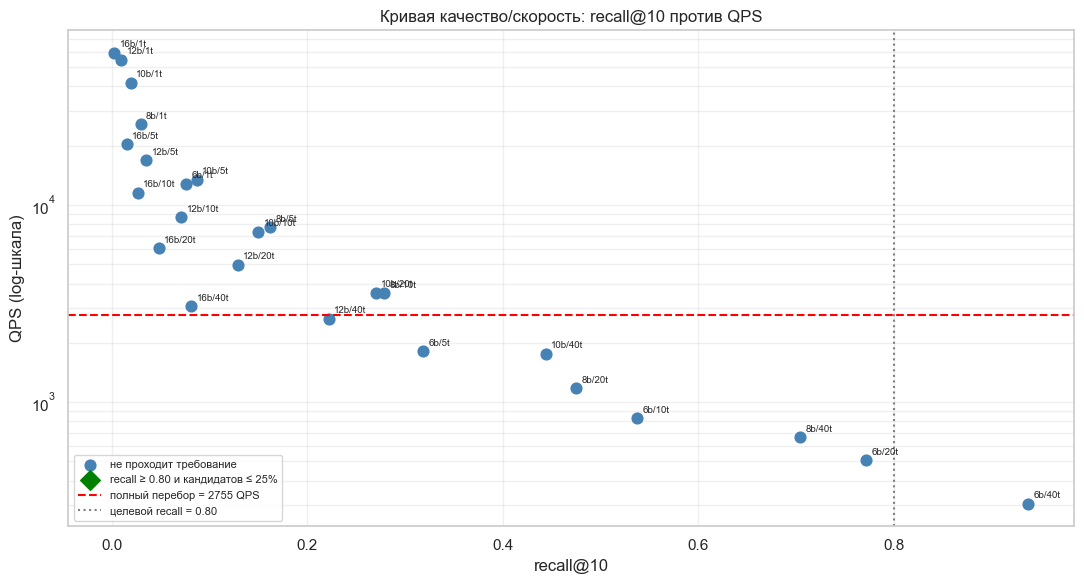

In [112]:
ok_mask = (grid["recall@10"] >= 0.80) & (grid["candidate_share"] <= 0.25)

plt.figure(figsize=(11, 6))
plt.scatter(grid.loc[~ok_mask, "recall@10"], grid.loc[~ok_mask, "qps"],
            s=60, color="steelblue", label="не проходит требование")
plt.scatter(grid.loc[ok_mask, "recall@10"], grid.loc[ok_mask, "qps"],
            s=100, color="green", marker="D", label="recall ≥ 0.80 и кандидатов ≤ 25%")

for _, r in grid.iterrows():
    plt.annotate(f"{int(r['n_bits'])}b/{int(r['n_tables'])}t",
                 (r["recall@10"], r["qps"]), fontsize=7,
                 xytext=(4, 4), textcoords="offset points")

plt.axhline(brute_qps, color="red", linestyle="--", label=f"полный перебор = {brute_qps:.0f} QPS")
plt.axvline(0.80, color="gray", linestyle=":", label="целевой recall = 0.80")
plt.yscale("log")
plt.title("Кривая качество/скорость: recall@10 против QPS")
plt.xlabel("recall@10")
plt.ylabel("QPS (log-шкала)")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
ok = grid[ok_mask].sort_values("qps", ascending=False)

if len(ok):
    print("конфигурации, проходящие требование:")
    display(ok.round(3))
    best = ok.iloc[0]
    best_config = {
        "n_bits": int(best["n_bits"]),
        "n_tables": int(best["n_tables"]),
        "recall_at_10": float(best["recall@10"]),
        "qps": float(best["qps"]),
        "candidate_share": float(best["candidate_share"]),
    }
    print(f"\nВЫБРАНА: n_bits={best_config['n_bits']}, n_tables={best_config['n_tables']}")
    print(f"  recall@10  = {best_config['recall_at_10']:.3f}")
    print(f"  кандидатов = {best['mean_candidates']:.0f} ({best_config['candidate_share']:.1%})")
    print(f"  QPS        = {best_config['qps']:.0f} против {brute_qps:.0f} у перебора "
          f"→ ускорение {best_config['qps'] / brute_qps:.1f}x")
else:
    best_config = None
    print("НИ ОДНА конфигурация не прошла требование.")
    print("Расширьте сетку: добавьте n_tables = 60, 80 при n_bits = 8 и 10.")

НИ ОДНА конфигурация не прошла требование.
Расширьте сетку: добавьте n_tables = 60, 80 при n_bits = 8 и 10.


---
## Блок 9. Качественная проверка выдачи

**Цель:** посмотреть на результат глазами, а не только на метрику.

**Сделайте:**
1. Функция `show_results(doc_id, method)` — печатает исходный документ (первые ~200 символов, его группу) и top-5 найденных: группа + фрагмент текста + score.
2. Прогоните **минимум 5 документов из разных групп** (например из `sci.space`, `rec.sport.hockey`, `talk.politics.mideast`, `comp.graphics`, `misc.forsale`).
3. Для каждого — одно предложение: релевантно / частично / мусор.
4. Посчитайте простую прокси-метрику качества: **доля соседей из той же группы**, что и запрос (по всей выборке запросов), отдельно для точного KNN и для LSH.

**Вывод:** совпадает ли ощущение от выдачи с recall@10? Бывают ли случаи, когда LSH нашёл *другие*, но по-прежнему осмысленные документы — и почему recall это штрафует?

In [ ]:
# ВАШ КОД — блок 9
# TODO: show_results, 5 примеров с комментариями, доля соседей той же группы
raise NotImplementedError("Блок 9")

---
## Блок 10. Итоги и артефакты

**Сделайте:**

1. Markdown-ячейку с итоговой таблицей:

| Метод | Recall@10 | QPS | Доля просмотренной коллекции | Когда применять |
|-------|-----------|-----|------------------------------|-----------------|
| Полный перебор | 1.00 | ? | 100% | ? |
| KD-дерево (d=256) | 1.00 | ? | — | ? |
| LSH (выбранная конфигурация) | ? | ? | ? | ? |

2. Сохраните `artifacts/metrics.json` с метриками и параметрами запуска.

3. Ответьте на вопросы самопроверки:
   - Почему recall@10 у LSH меньше единицы, хотя точное расстояние на втором этапе считается честно? В какой момент теряется сосед?
   - Почему увеличение числа бит **снижает** recall, хотя подпись становится информативнее?
   - Почему KD-дерево на `d = 256` проиграло полному перебору, хотя формально его сложность `O(log N)`?
   - Зачем нужна L2-нормализация перед косинусным поиском и что она даёт по скорости?
   - Ваш индекс живёт в проде, документы добавляются и удаляются каждый день. Что сломается в вашей реализации LSH и как вы это почините?

In [ ]:
# ВАШ КОД — блок 10
metrics = {
    "brute_qps": None,            # TODO
    "lsh_best": {
        "n_bits": None,           # TODO
        "n_tables": None,         # TODO
        "recall_at_10": None,     # TODO
        "qps": None,              # TODO
        "candidate_share": None,  # TODO
    },
    "kdtree_slowdown_at_256": None,  # во сколько раз медленнее brute
    "params": {
        "sample_size": SAMPLE_SIZE,
        "svd_components": SVD_COMPONENTS,
        "top_k": TOP_K,
        "n_queries": N_QUERIES,
        "random_state": RANDOM_STATE,
    },
}

# TODO: заполнить metrics и сохранить
# (ARTIFACTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")
raise NotImplementedError("Блок 10")

---
## Критерии оценки (ориентир)

| Блок | Что оценивается | Баллы |
|------|-----------------|-------|
| 1–2 | Загрузка, фильтрация, EDA с выводами | 10 |
| 3–4 | TF-IDF, LSA, нормализация, оценка памяти | 15 |
| 5 | Точный KNN, корректный ground truth, честный замер QPS | 15 |
| 6 | Деревья на разных размерностях, график, объяснение проклятия размерности | 20 |
| 7 | Рабочая реализация LSH с нуля | 20 |
| 8 | Двухэтапный поиск, сетка экспериментов, кривая recall/QPS, выбор точки | 15 |
| 9–10 | Качественная проверка, выводы, `metrics.json` | 5 |

**Достижение целевой точки** (recall@10 ≥ 0.80 при доле кандидатов ≤ 25%) — обязательное условие для полного балла за блок 8.

### Бонусы

- **+5** — **SimHash-дедупликация:** найдите в корпусе почти-дубликаты (документы с расстоянием Хэмминга между подписями ≤ 3 бит при `n_bits = 64`) и выведите несколько пар. Совпадают ли они на глаз?
- **+5** — **Сравнение с production-решением:** поставьте `hnswlib` или `annoy`, постройте индекс на тех же эмбеддингах, нанесите его точки на ту же кривую recall/QPS. Насколько LSH проигрывает графовому методу?
- **+5** — **Мульти-проба (multi-probe LSH):** помимо бакета запроса просматривайте бакеты, отличающиеся на 1 бит. Как это сдвигает кривую recall/QPS по сравнению с простым увеличением числа таблиц?